# Homework II - Programing

Grupo 55
109247 - Ema Ferrão
109989 - Pedro Aldeia

Use  the  Breast_cancer_dataset.csv  dataset  available at the course’s webpage and, using 
sklearn, apply a 5-fold stratified cross-validation with shuffling for the assessment of predictive 
models along this section.

### Setup and Data Loading

In [19]:
#import libraries

import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from statistics import mean
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import ttest_ind, ttest_rel
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score



In [20]:
#load data

df = pd.read_csv('Breast_cancer_dataset.csv')

In [21]:
#check data

print("First 5 rows: ", "\n\n", df.head())

First 5 rows:  

          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area

In [22]:
# Display basic information

print("\n" + "=" * 190)
print("Dataset Overview:")
print("=" * 190)

print(f"Dataset shape: {df.shape}")

feature_names = df.columns[:-1].tolist()
print(f"Features ({len(feature_names)}): {feature_names}")

print(f"\nTarget variable: diagnosis -> {df['diagnosis'].unique()}")
print(f"Class distribution:")
print(df['diagnosis'].value_counts())
print(f"Class balance:")
print(df['diagnosis'].value_counts(normalize=True).round(3))

print("\n" + "=" * 190)


Dataset Overview:
Dataset shape: (569, 33)
Features (32): ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Target variable: diagnosis -> ['M' 'B']
Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64
Class balance:
diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64



In [23]:
# Check for missing values

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print("Missing Values Summary:")
    print(missing_summary)
else:
    print("No missing values detected in the dataset.")

Missing Values Summary:
                  Column  Missing_Count  Missing_Percentage
Unnamed: 32  Unnamed: 32            569               100.0


In [24]:
# Understand missing values pattern

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [25]:
# Fix missing data (or, in this case, remove the unnecessary column)

df = df.drop(columns=['Unnamed: 32'])

In [26]:
# Check for missing values again

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print("Missing Values Summary:")
    print(missing_summary)
else:
    print("No missing values detected in the dataset.")

No missing values detected in the dataset.


In [27]:
# Prepare data for modeling

# Note: We used a random state for the sake of reproducibility
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Note: We drop 'id' because it's not a predictive feature
X, y = df.drop(columns=['diagnosis', 'id']), df['diagnosis']

## 1.
### a)
Compute the accuracies for each classifier. Which is more stable than the 
other regarding performance, and why? 

In [28]:
# Create classifiers and compute accuracies

KNN_classifier = KNeighborsClassifier(5)
GaussianNB_classifier = GaussianNB()

KNN_scores = cross_val_score(KNN_classifier, X, y, cv=skf)
Gaussian_scores = cross_val_score(GaussianNB_classifier, X, y, cv=skf)

print("=" * 80 + "\n")
print("KNN scores: ", KNN_scores, "\nKNN mean: ", round(KNN_scores.mean(), 8), "\nGaussian Naive Bayes: ", Gaussian_scores, "\nGaussian Naive Bayes mean: ", round(Gaussian_scores.mean(), 8))
print("\n" + "=" * 80)


KNN scores:  [0.92982456 0.90350877 0.92982456 0.95614035 0.95575221] 
KNN mean:  0.93501009 
Gaussian Naive Bayes:  [0.96491228 0.90350877 0.92982456 0.92982456 0.96460177] 
Gaussian Naive Bayes mean:  0.93853439



In [29]:
# Compute means and variances of the accuracies for easier comparison

KNN_mean = mean(KNN_scores)
Gaussian_mean = mean(Gaussian_scores)
KNN_variance = 0
Gaussian_variance = 0

for i in range(5):
    KNN_variance += np.square(KNN_mean - KNN_scores[i])
    Gaussian_variance += np.square(Gaussian_mean - Gaussian_scores[i])

KNN_variance /= 5
Gaussian_variance /= 5

KNN_std_dev = np.sqrt(KNN_variance)
Gaussian_std_dev = np.sqrt(Gaussian_variance)

print("=" * 80 + "\n")
print("KNN Standard Deviation: ", round(KNN_std_dev, 8))
print("Gaussian Standard Deviation: ", round(Gaussian_std_dev, 8), "\n")
if KNN_std_dev < Gaussian_std_dev:
    print("KNN is more stable than Gaussian Naive Bayes for this data set.")
else:
    print("Gaussian Naive Bayes is more stable than KNN for this data set.")
print("\n" + "=" * 80)


KNN Standard Deviation:  0.01961039
Gaussian Standard Deviation:  0.02346835 

KNN is more stable than Gaussian Naive Bayes for this data set.



KNN is more stable than the GaussianNB for this example because its variance is smaller than the Gaussian Naive Bayes'. This can be the case because of several factors, for example:
 - Gaussian Naive Bayes relies on the assumption that each feature has an independent probability to the other, when in reality they might be significantly correlated;
 - KNN's performance is best with a lot of high quality data, similar feature values will result in the same diagnosis.

### b)
Provide the accuracy of the kNN model, this time preprocessing the data with 
a Min-Max scaler before training the model. Explain the impact that this step has 
on the performance of the model, providing an explanation for the results.

In [30]:
# Compute accuracies with Min-Max preprocessing for KNN

knn_pipe = make_pipeline(MinMaxScaler(), KNeighborsClassifier())
KNN_MinMax_scores = cross_val_score(knn_pipe, X, y, cv=skf)

print("=" * 120 + "\n")
print("KNN scores: ", KNN_scores)
print("KNN scores with MinMax preprocessing: ", KNN_MinMax_scores)
print("\n" + "=" * 120)


KNN scores:  [0.92982456 0.90350877 0.92982456 0.95614035 0.95575221]
KNN scores with MinMax preprocessing:  [0.98245614 0.95614035 0.92982456 0.98245614 0.96460177]



In [31]:
# Print averages for easier comparison
print("=" * 80 + "\n")
print("KNN average accuracy: ", round(mean(KNN_scores), 8))
print("KNN average score with MINMAX pre-processing: ", round(mean(KNN_MinMax_scores), 8))
print("MinMax scaling improvement: ", round(KNN_MinMax_scores.mean() - KNN_scores.mean(), 8))
print("\n" + "=" * 80)


KNN average accuracy:  0.93501009
KNN average score with MINMAX pre-processing:  0.96309579
MinMax scaling improvement:  0.0280857



Scaling the dataset can significantly impact the performance of the KNN algorithm, since KNN's predictions rely on distance measures. Some features might have larger ranges than others, which would account for a disproportionate influence to the total distance. Normalizing variable values ensures that each feature contributes equally for the distance calculus.

As expected, KNN achives higher accuracy rates when the data is pre-processed, with a 2.8% improvement to its counterpart.

### c)
Using  scipy,  determine  whether  the  scaled 𝑘𝑁𝑁  model  is  statistically
superior to Naïve Bayes (also scaled) when it comes to accuracy, and justify your 
result.

In [32]:
# Compute accuracies with Min-Max preprocessing for GaussianNB

gaussianNB_pipe = make_pipeline(MinMaxScaler(), GaussianNB())
GaussianNB_MinMax_scores = cross_val_score(gaussianNB_pipe, X, y, cv=skf)

# H0: KNN accuracy is not statistically superior to GaussianNB accuracy
# H1: KNN accuracy is statistically superior to GaussianNB accuracy
result = ttest_rel(KNN_MinMax_scores, GaussianNB_MinMax_scores, alternative='greater')

In [33]:
# Print statistical relevance results (using t-test)

print("=" * 120 + "\n")
print("p-value: ", round(result.pvalue, 8))
confidence_levels = []

# H0 rejected: KNN accuracy is statistically superior to GaussianNB accuracy for the given confidence levels
if result.pvalue > 0.01:
    confidence_levels.append("99%")
    if result.pvalue > 0.05:
        confidence_levels.append("95%")
        if result.pvalue > 0.1:
            confidence_levels.append("90%")
    print("\nThe scaled KNN is statistically superior to its Naive Bayes counterpart for the following confidence levels: ", confidence_levels)
    
# H0 accepted: KNN accuracy is not statistically superior to GaussianNB accuracy
else:
    print("\nThe scaled KNN is not statistically superior to its Naive Bayes counterpart.")
print("\n" + "=" * 120)


p-value:  0.03380948

The scaled KNN is statistically superior to its Naive Bayes counterpart for the following confidence levels:  ['99%']



***
## 2.
Using a 70-30 train-test split, vary the number of neighbors of a 𝑘𝑁𝑁 classifier using 𝑘={1, 5, 10, 15, 20, 25}. Additionally, for each, train one classifier using uniform weights and distance weights.

In [34]:
# Spliting data and checking class distribution in train and test sets

# Note: We used a random state for the sake of reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42, stratify=y)

print("=" * 80 + "\n")
print("Check set class distribution")
print("\n" + "=" * 80 + "\n")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))
print("\n" + "=" * 80)



Check set class distribution


Training set size: 398 samples
Test set size: 171 samples

Training set class distribution:
diagnosis
B    0.628
M    0.372
Name: proportion, dtype: float64

Test set class distribution:
diagnosis
B    0.626
M    0.374
Name: proportion, dtype: float64



In [35]:
# Compute accuracies for different k values and weight options

k_values = [1, 5, 10, 15, 20, 25]
uniform_scores = []
weighted_scores = []
uniform_train_scores = []
weighted_train_scores = []

for k in k_values:
    uniform_knn = KNeighborsClassifier(k).fit(X_train, y_train)
    weighted_knn = KNeighborsClassifier(k, weights='distance').fit(X_train, y_train)

    uniform_train_scores.append(uniform_knn.score(X_train, y_train))
    weighted_train_scores.append(weighted_knn.score(X_train, y_train))
    uniform_scores.append(uniform_knn.score(X_test, y_test))
    weighted_scores.append(weighted_knn.score(X_test, y_test))

### a)
Plot the train and test accuracies for each model.

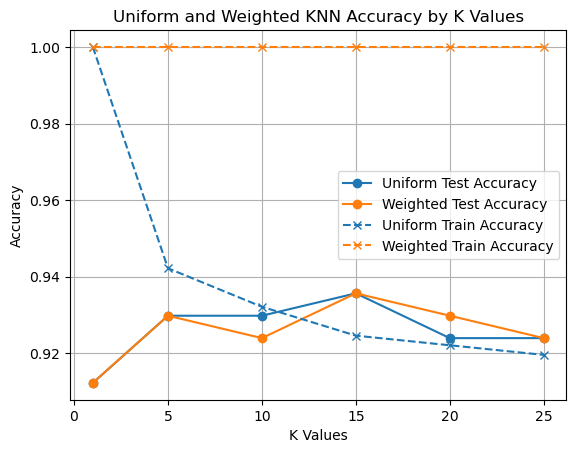

In [36]:
# Plotting the results

plt.plot(k_values, uniform_scores, label="Uniform Test Accuracy", marker='o', color='tab:blue')
plt.plot(k_values, weighted_scores, label="Weighted Test Accuracy", marker='o', color='tab:orange')
plt.plot(k_values, uniform_train_scores, label="Uniform Train Accuracy", linestyle='--', marker='x', color='tab:blue')
plt.plot(k_values, weighted_train_scores, label="Weighted Train Accuracy", linestyle='--', marker='x', color='tab:orange')
plt.xlabel("K Values")
plt.ylabel("Accuracy")
plt.title("Uniform and Weighted KNN Accuracy by K Values")
plt.legend()
plt.grid(True)

plt.show()

### b) 
Explain  the  impact  of  increasing  the  number  of  neighbors  on  the 
generalization ability of the models. Elaborate on the trade-offs between small and 
large values of k and suggest its optimal value.

Increasing the k-value in the kNN algorithm enables us to consider a wider range of observations, resulting in a more general prediction. For better results, we need to find the sweet-spot, a low k-value will most likelly lead to overfitting (too focused in similar observations) and a value too high won't give enough importance to the test itself (too general). The optimal k-value for this dataset is 15 for both models, as we can see from the previous plot.

***
## 3. 
Suppose you must deploy either kNN or Naïve Bayes in a clinical setting for breast 
cancer  diagnosis.  Discuss  at  least  two  factors  that  would  influence  your  choice, 
referencing insights from your experiments. Comment on the models’ performance with 
medical datasets and the overall models’ characteristics from a more technical context 
(e.g., interpretability, computational cost, or scalability). 

A model that does not have high accuracy would not be reliable for this purpose, because a mistake could cost someone's life. Even though they are not perfect, kNN and Naive Bayes have proven to be pretty reliable, with about 0,935 accuracy. As a conclusion to exercise 1a, scaled kNN's statistical significance is debatable, our test significance would need to be at least 96,62% to consider this true.

High recall should be a big priority when choosing the model, for it is very dangerous to not diagnose a diseased person. In a clinical context, probability thresholds are usually tuned down in order to increase recall, even if it means lowering our accuracy and occasionally misdiagnosing someone. For Naive Bayes, it is very simple to lower that probability threshold, but kNN does not rely on probabilities, which might mean that the threshold cannot be lowered for this model. Another problem that might arise from using the kNN algorithm is that rare diseases will probably not be diagnosed often, as kNN bases its predictions on similar cases.

Also, it is crucial to have consistent models in order to trust its results. Both kNN and Naive Bayes seem to have very good consistency, but kNN proved to be a little bit more consistent, with only 0,019 standard deviation, compared to Naive Bayes' 0,023.

In terms of computational cost and scalability, Naive Bayes comes as a clear winner. kNN has no pre-processing, the distances are calculated every time we execute the code. However, for Naive Bayes, we only have to compare the results to the probabilities computed in pre-processing. Naive Bayes comes off with a complexity of O(f) while kNN has O(f.N) (f->number of features; N->number of observations on dataset). This makes Naive Bayes much more computationally cheaper and scalable than kNN.

While kNN is the most intuitive, both models are fairly easy to interpret. kNN considers the most similar cases and decides based on them (optionally giving different weights to each case). Naive Bayes assumes that every tested variable is independent from each other and using the training data calculates the probability of a variable corresponding to a certain result. The output of the model will be the multiplication of the probabilities for the values observed in the input.

In the end, the choice depends on context and priorities:
- kNN offers better predictive performance, consistency and intuitive reasoning based on similar cases,
- Naïve Bayes provides higher computational efficiency and faster, easier deployment.   

Recall was not tested in this project, but Naive Bayes would most likelly come off as a better option taking it into consideration.
